#Object Detection using YOLOV8

##Generate your kaggle token from profile and upload the json file in the cell below

In [2]:
from google.colab import files
files.upload()  # Upload kaggle.json here


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"zeeshan","key":"KGAT_1b934d6d31b7c95f52686c4ad6a78f8b"}'}

##Create a directory for kaggle datasets

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

##Download the required dataset

In [4]:
!kaggle datasets download -d alincijov/self-driving-cars
!unzip self-driving-cars.zip -d self-driving-cars/

Streaming output truncated to the last 5000 lines.
  inflating: self-driving-cars/images/1479502279230178611.jpg  
  inflating: self-driving-cars/images/1479502279730506173.jpg  
  inflating: self-driving-cars/images/1479502280230536426.jpg  
  inflating: self-driving-cars/images/1479502280730839737.jpg  
  inflating: self-driving-cars/images/1479502281729824146.jpg  
  inflating: self-driving-cars/images/1479502282229848985.jpg  
  inflating: self-driving-cars/images/1479502282730102580.jpg  
  inflating: self-driving-cars/images/1479502283731724690.jpg  
  inflating: self-driving-cars/images/1479502284232432719.jpg  
  inflating: self-driving-cars/images/1479502285221790200.jpg  
  inflating: self-driving-cars/images/1479502285730163274.jpg  
  inflating: self-driving-cars/images/1479502286231098378.jpg  
  inflating: self-driving-cars/images/1479502287230097438.jpg  
  inflating: self-driving-cars/images/1479502287730246905.jpg  
  inflating: self-driving-cars/images/147950228823126

<div style="border-radius:10px; border:#f79a05 solid; padding: 15px; background-color: #f5d77f; font-size:100%; text-align:left">

<h3 align="left"><font color='#f79a05'>💡 Inspiration:</font></h3>
    
**Purpose**: to object detection in images by using **YOLOv8**.

**Object detection** is a computer technology related to computer vision and image processing that deals with detecting instances of semantic objects of a certain class (such as humans, buildings, or cars) in digital images and videos.
When it comes to object detection, popular detection frameworks are

* YOLO
* SSD
* Faster R-CNN


# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> What is YOLO exactly?</p>

<div style="border-radius:10px; border:#f79a05 solid; padding: 15px; background-color: #f5d77f; font-size:100%; text-align:left">

<h3 align="left"><font color='black'>What is YOLO exactly?</font></h3>
    
**YOLO** (You Only Look Once) is a method / way to do object detection. It is the algorithm /strategy behind how the code is going to detect objects in the image.

Earlier detection frameworks, looked at different parts of the image multiple times at different scales and repurposed image classification technique to detect objects. This approach is slow and inefficient.

YOLO takes entirely different approach. It looks at the entire image only once and goes through the network once and detects objects. Hence the name. It is very fast. That’s the reason it has got so popular.

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> Import Libraries</p>

In [5]:
import numpy as np
import pandas as pd
import cv2

from sklearn.utils import shuffle
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

import warnings

warnings.simplefilter('ignore')

### <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> Load data</p>

In [6]:
df = pd.read_csv('self-driving-cars/labels_train.csv')
df = shuffle(df)
# shuffle here is used to rearrange the data.
df.head()

,frame,xmin,xmax,ymin,ymax,class_id
113938,1479504679373258332.jpg,342,350,134,161,3
12638,1478021875081281646.jpg,273,315,135,168,1
14471,1478731939586542390.jpg,133,165,138,165,1
112443,1479504562883204856.jpg,170,184,142,153,1
12997,1478021908083034967.jpg,457,464,141,155,1


<div style="border-radius:10px; border:#f79a05 solid; padding: 15px; background-color: #f5d77f; font-size:100%; text-align:left">
    
 * This dataset is mostly a practice and training aspect for the subject of YOLO. The data is labeled with 5 classes.
 * classic_id labels: 'car', 'truck', 'pedestrian', 'bicyclist', 'light'

In [24]:
classes = df.class_id.unique()
print(classes)

[3 1 5 2 4]


In [25]:
labels = { 1:'car', 2:'truck', 3:'person', 4:'bicycle', 5:'traffic light'}

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> Show some labeled images</p>

In [28]:
# Get path images and boxes (x,y) for each class_id
boxes = {}
images = {}

base_path = 'self-driving-cars/images/'

for class_id in classes:
    first_row = df[df['class_id'] == class_id].iloc[0]

    images[class_id] = cv2.imread(base_path + first_row['frame'])
    boxes[class_id] = [first_row['xmin'],first_row['xmax'],first_row['ymin'],first_row['ymax']]

- For each class_id, the code finds one matching image, loads it, and stores its bounding-box coordinates.

- For every class → find its first image → load the image → get its bounding box coordinates → store both.

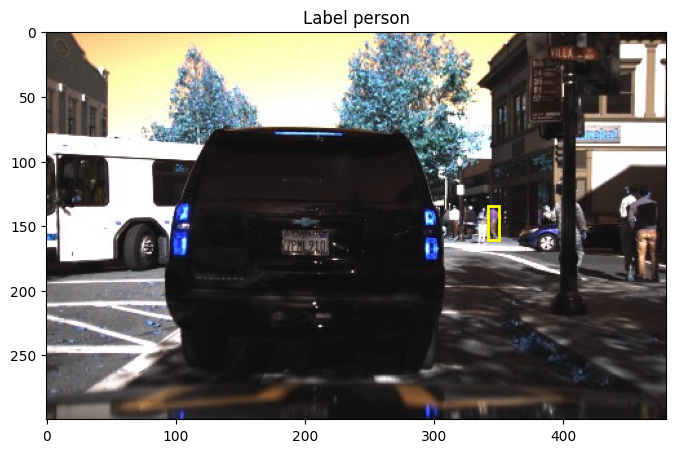

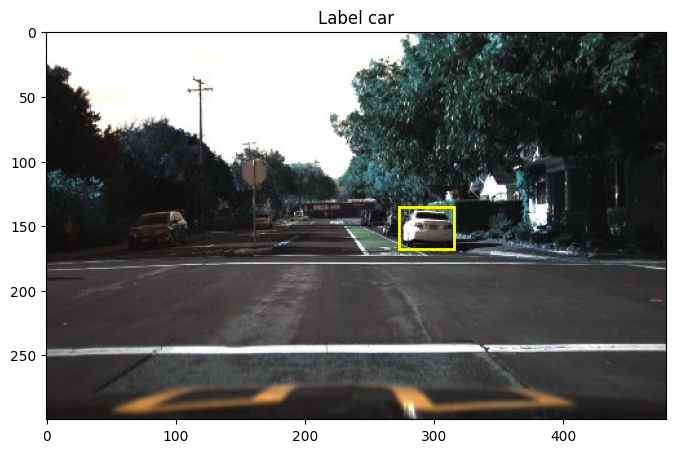

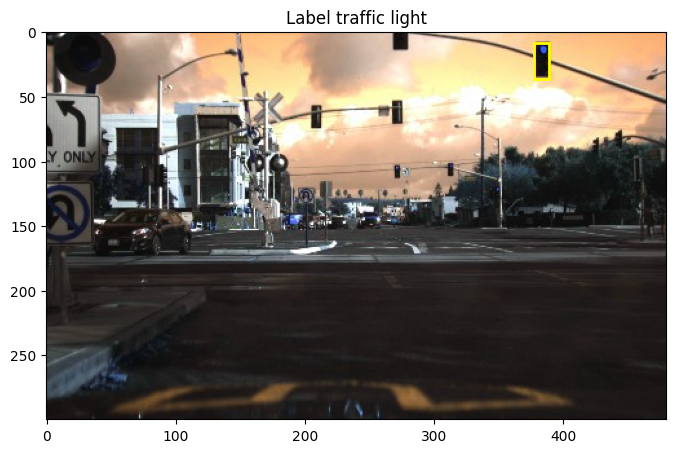

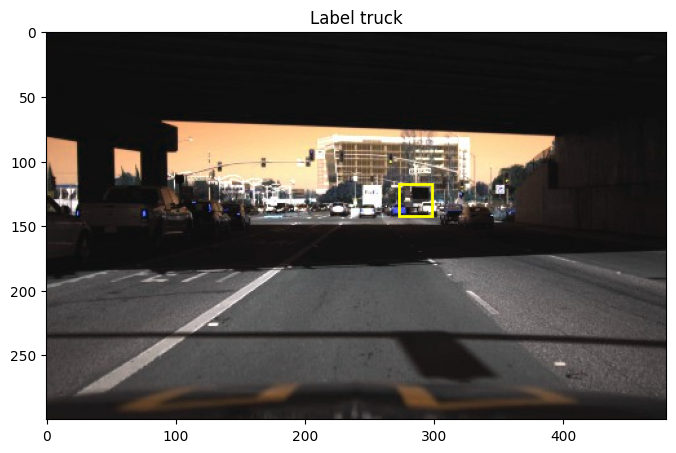

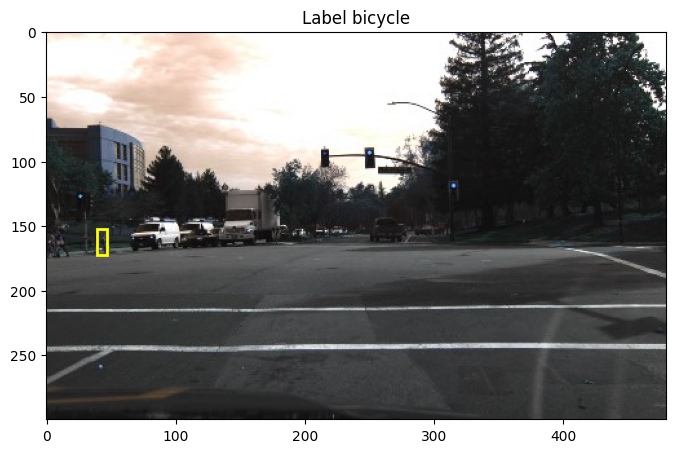

In [29]:
for i in classes:

    xmin, xmax, ymin, ymax = boxes[i][0], boxes[i][1], boxes[i][2], boxes[i][3]

    plt.figure(figsize=(8, 10))
    plt.title("Label " + labels[i])
    plt.imshow(images[i])
    plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, color='yellow', fill=False, linewidth=2))

    plt.show()

# <p style="font-family:JetBrains Mono; font-weight:bold; letter-spacing: 2px; color:#9c7606; font-size:140%; text-align:left;padding: 10px; border-bottom: 2px solid #f79a05"> Model</p>

In [30]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.9 MB/s eta 0:00:00


In [31]:
from ultralytics import YOLO
# Imports the YOLO model from the Ultralytics library. This is the main library used here for training and running YOLO.
import PIL
# Imports the PIL (Pillow) image-processing library.
from PIL import Image
# Imports Image from Pillow, which is used to open and work with image files.
from IPython.display import display
# Allows images and other objects to be displayed directly in the Jupyter Notebook.
import os
# Provides functions for working with files and folders/paths.
import pathlib
# Provides tools for handling file and directory paths in a convenient way.

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [32]:
model = YOLO("yolov8m.pt")

In [43]:
results=model.predict(source="self-driving-cars/images/1478019956680248165.jpg",
              save=True, conf=0.2,iou=0.5)


image 1/1 /content/self-driving-cars/images/1478019956680248165.jpg: 416x640 1 car, 1 truck, 1018.3ms
Speed: 3.3ms preprocess, 1018.3ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict


- results = model.predict(...) → Runs YOLO on the given image and stores the detection results.
- source → Specifies the image to detect objects in.
- save=True → Saves the image with detected bounding boxes.
- conf=0.2 → Keeps detections with at least 20% confidence.
- iou=0.5 → Controls how overlapping bounding boxes are filtered.
- results → Contains the detected objects, boxes, confidence scores, etc.

In [44]:
result = results[0]
box = result.boxes[0]

In [45]:
for result in results:
    boxes = result.boxes  # Boxes object for bbox outputs
    masks = result.masks  # Masks object for segmentation masks outputs
    probs = result.probs  # Class probabilities for classification outputs

In [46]:
cords = box.xyxy[0].tolist()
class_id = box.cls[0].item()
conf = box.conf[0].item()
print("Object type:", class_id)
print("Coordinates:", cords)
print("Probability:", conf)

Object type: 2.0
Coordinates: [124.69143676757812, 142.6882781982422, 148.7809295654297, 162.10047912597656]
Probability: 0.7161701321601868


- cords = box.xyxy[0].tolist() → Gets the bounding-box coordinates as [xmin, ymin, xmax, ymax] and converts them to a Python list.
- class_id = box.cls[0].item() → Gets the class ID of the detected object.
- conf = box.conf[0].item() → Gets the model's confidence score for that detection.
- print("Object type:", class_id) → Prints the detected object's class ID.
- print("Coordinates:", cords) → Prints the object's bounding-box coordinates.
- print("Probability:", conf) → Prints how confident YOLO is about the detection.

In [47]:
for box in result.boxes:
    class_id = result.names[box.cls[0].item()]
    cords = box.xyxy[0].tolist()
    cords = [round(x) for x in cords]
    conf = round(box.conf[0].item(), 2)
    print("Object type:", class_id)
    print("Coordinates:", cords)
    print("Probability:", conf)
    print("---")

Object type: car
Coordinates: [125, 143, 149, 162]
Probability: 0.72
---
Object type: truck
Coordinates: [141, 139, 157, 154]
Probability: 0.31
---


- for box in result.boxes: → Loops through every detected object in the image.
- class_id = result.names[box.cls[0].item()] → Gets the name of the detected class (e.g., car, person) using its class ID.
- cords = box.xyxy[0].tolist() → Gets the bounding-box coordinates as a list.
- cords = [round(x) for x in cords] → Rounds the coordinates to whole numbers.
- conf = round(box.conf[0].item(), 2) → Gets the confidence score and rounds it to 2 decimal places.
- print("Object type:", class_id) → Prints the object's class name.
- print("Coordinates:", cords) → Prints the bounding-box coordinates.
- print("Probability:", conf) → Prints the confidence score.
- print("---") → Prints a separator between detections.

In [48]:
results1 = model.predict(source="self-driving-cars/images/1478020211690815798.jpg",
              save=True, conf=0.2,iou=0.5)

Results = results1[0]


image 1/1 /content/self-driving-cars/images/1478020211690815798.jpg: 416x640 4 cars, 3 traffic lights, 1116.5ms
Speed: 3.0ms preprocess, 1116.5ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict


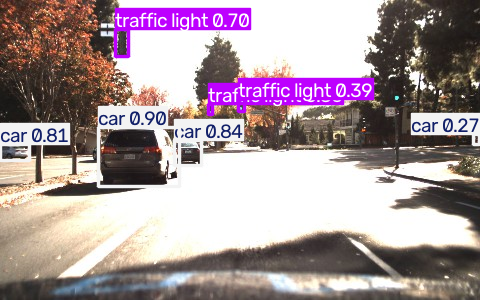

In [50]:
# Plotting results
plot = results1[0].plot()
plot = cv2.cvtColor(plot, cv2.COLOR_BGR2RGB)
display(Image.fromarray(plot))

##Exercise (Object-Detection Visualization)
**Using the concepts from the notebook—loading annotations from a CSV, reading images, and drawing bounding boxes—write a short script that:**

1. Loads the labels_train.csv into a pandas DataFrame.

2. Randomly selects one image filename from the DataFrame.

3. Reads its image file from self-driving-cars/images/.

4. Filters the DataFrame to get all bounding-box annotations for that image (columns: xmin, ymin, xmax, ymax and class).

5. Draws each box (and class label) onto the image using PIL.ImageDraw.

6. Displays the resulting annotated image.



In [51]:
df_2 = pd.read_csv('self-driving-cars/labels_train.csv')
df_2 = shuffle(df_2)
df_2.head()

,frame,xmin,xmax,ymin,ymax,class_id
62404,1478899005004198528.jpg,218,222,121,128,5
104271,1479503818313251990.jpg,218,232,144,158,1
8090,1478020828711297010.jpg,149,163,133,144,1
92841,1479502535226394795.jpg,263,310,119,160,2
96081,1479502831266700209.jpg,392,456,121,139,1


In [54]:
img_name = df_2['frame'].sample(1).iloc[0]

In [55]:
img_name

'1479503986332985449.jpg'

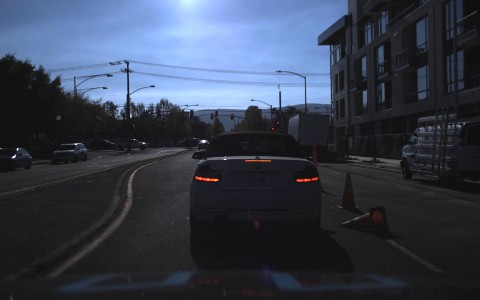

In [56]:
from PIL import Image

image = Image.open("self-driving-cars/images/" + img_name)
display(image)

In [57]:
annotations = df_2[df_2['frame']==img_name]
annotations

,frame,xmin,xmax,ymin,ymax,class_id
105682,1479503986332985449.jpg,90,114,139,148,1
105687,1479503986332985449.jpg,287,330,112,155,2
105683,1479503986332985449.jpg,117,147,138,150,1
105681,1479503986332985449.jpg,52,88,142,163,1
105685,1479503986332985449.jpg,185,324,127,234,1
105688,1479503986332985449.jpg,399,479,107,187,1
105680,1479503986332985449.jpg,1,32,146,170,1
105686,1479503986332985449.jpg,197,209,140,150,1
105684,1479503986332985449.jpg,184,202,137,148,1


In [59]:
from PIL import ImageDraw
draw = ImageDraw.Draw(image)

In [62]:
for _,row in annotations.iterrows() :
  draw.rectangle(
      (row['xmin'], row['ymin'], row['xmax'], row['ymax']),
      outline='red',
      width=2
  )
  draw.text(
      (row['xmin'], row['ymin']),
      str(row['class_id']),
      fill='red'
  )

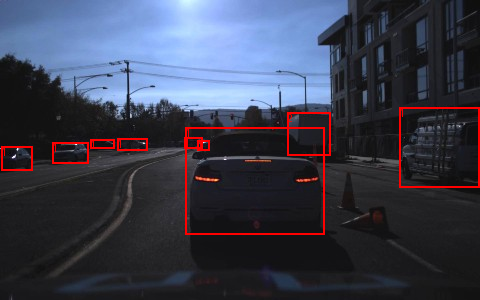

In [63]:
display(image)